In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')

df.head()
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
df = df.dropna(subset=['CustomerID']).copy()
df_sales = df[df['Quantity'] != 0]
df_sales['CustomerID'] = df_sales['CustomerID'].astype(int).astype(str)
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])
df_sales['NetRevenue'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales.head(10)



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,NetRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08


In [3]:
df_sales = df_sales.groupby(
    ['InvoiceNo', 'StockCode', 'CustomerID', 'InvoiceDate'], as_index=False
).agg({
    'Quantity': 'sum',
    'NetRevenue': 'sum',
    'Country': 'first',
    'UnitPrice': 'mean'
    
})
df_sales.head(10)

,InvoiceNo,StockCode,CustomerID,InvoiceDate,Quantity,NetRevenue,Country,UnitPrice
0,536365,21730,17850,2010-12-01 08:26:00,6,25.50,United Kingdom,4.25
1,536365,22752,17850,2010-12-01 08:26:00,2,15.30,United Kingdom,7.65
2,536365,71053,17850,2010-12-01 08:26:00,6,20.34,United Kingdom,3.39
3,536365,84029E,17850,2010-12-01 08:26:00,6,20.34,United Kingdom,3.39
4,536365,84029G,17850,2010-12-01 08:26:00,6,20.34,United Kingdom,3.39
5,536365,84406B,17850,2010-12-01 08:26:00,8,22.00,United Kingdom,2.75
6,536365,85123A,17850,2010-12-01 08:26:00,6,15.30,United Kingdom,2.55
7,536366,22632,17850,2010-12-01 08:28:00,6,11.10,United Kingdom,1.85
8,536366,22633,17850,2010-12-01 08:28:00,6,11.10,United Kingdom,1.85
9,536367,21754,13047,2010-12-01 08:34:00,3,17.85,United Kingdom,5.95


In [4]:
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M')
df_sales['CohortMonth'] = df_sales.groupby('CustomerID')['InvoiceMonth'].transform('min')
df_sales['CohortIndex'] = (df_sales['InvoiceMonth'] - df_sales['CohortMonth']).apply(lambda x: x.n)

In [5]:
cohort_data = df_sales.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_data
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_size = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_size, axis=0)
retention.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.38,0.33,0.39,0.36,0.40,0.38,0.35,0.35,0.39,0.37,0.50,0.27
2011-01,1.0,0.24,0.28,0.24,0.33,0.30,0.26,0.26,0.31,0.35,0.37,0.15,NaN
2011-02,1.0,0.25,0.19,0.28,0.27,0.25,0.26,0.28,0.26,0.31,0.09,NaN,NaN
2011-03,1.0,0.19,0.25,0.22,0.23,0.18,0.26,0.24,0.29,0.09,NaN,NaN,NaN
2011-04,1.0,0.23,0.22,0.21,0.21,0.24,0.23,0.26,0.08,NaN,NaN,NaN,NaN
2011-05,1.0,0.24,0.17,0.17,0.22,0.24,0.27,0.10,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.21,0.19,0.27,0.25,0.34,0.10,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.21,0.20,0.23,0.27,0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.25,0.25,0.25,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


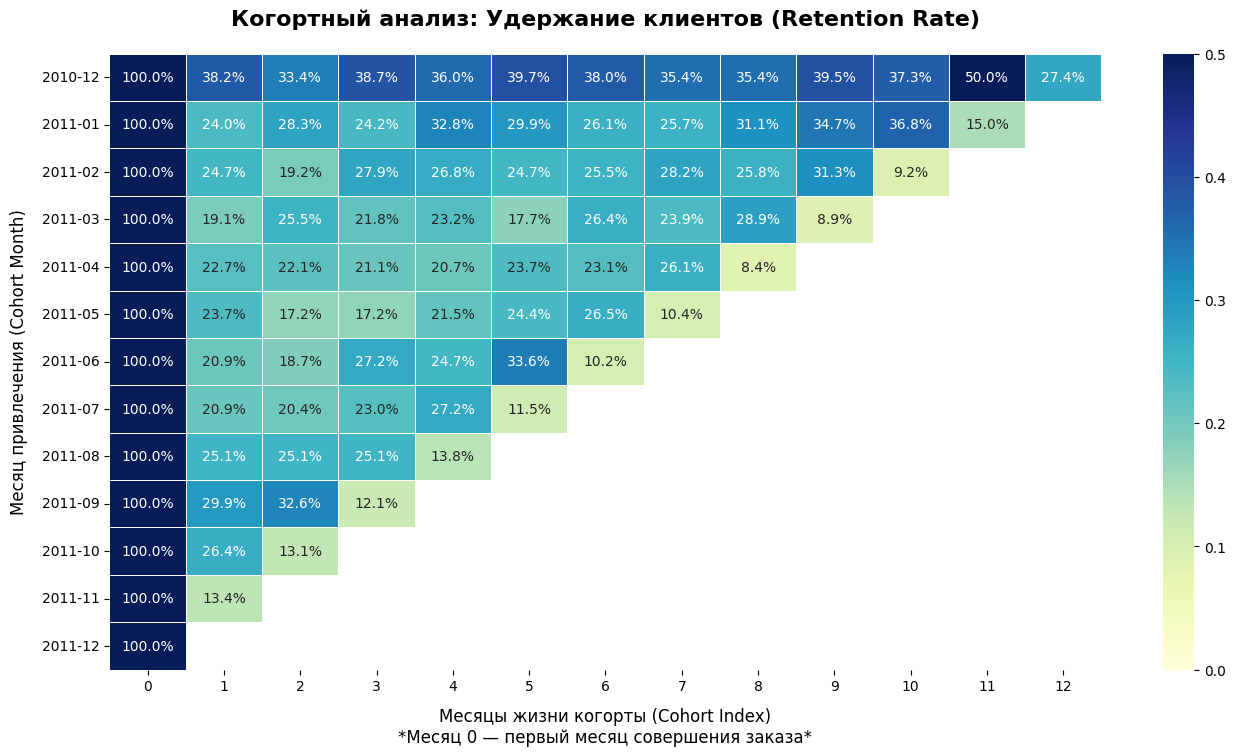

In [6]:
plt.figure(figsize=(16, 8))
sns.heatmap(
            retention,
            annot=True,
            cmap='YlGnBu',
            fmt='.1%',
            vmin=0.0,
            vmax=0.5,
            linewidths=0.5
)
plt.title('Когортный анализ: Удержание клиентов (Retention Rate)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Месяцы жизни когорты (Cohort Index)\n*Месяц 0 — первый месяц совершения заказа*', fontsize=12, labelpad=10)
plt.ylabel('Месяц привлечения (Cohort Month)', fontsize=12, labelpad=10)
plt.yticks(rotation = 0)
plt.savefig('retention_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
cohort_revenue = df_sales.groupby(['CohortMonth', 'CohortIndex'])['NetRevenue'].sum().reset_index()
revenue_matrix = cohort_revenue.pivot(index = 'CohortMonth', columns = 'CohortIndex', values = 'NetRevenue')
cumulative_revenue = revenue_matrix.cumsum(axis=1)
ltv_matrix = cumulative_revenue.divide(cohort_size, axis=0)
ltv_matrix.round(2)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,585.03,871.54,1115.06,1434.16,1646.11,1985.36,2315.42,2636.00,2963.93,3456.11,3919.02,4458.03,4650.87
2011-01,483.27,616.69,764.59,863.20,1058.72,1258.27,1425.06,1598.18,1774.98,2022.44,2312.29,2378.44,NaN
2011-02,393.48,459.95,558.52,679.18,773.04,854.84,980.27,1127.22,1263.70,1423.03,1447.68,NaN,NaN
2011-03,431.66,491.62,613.65,705.30,811.57,898.75,1036.53,1176.77,1325.19,1350.76,NaN,NaN,NaN
2011-04,400.55,497.28,580.65,660.55,747.53,846.71,941.10,1054.44,1075.49,NaN,NaN,NaN,NaN
2011-05,415.26,478.58,546.23,610.35,705.66,823.77,936.32,974.42,NaN,NaN,NaN,NaN,NaN
2011-06,393.73,451.68,510.81,638.15,748.09,917.30,951.02,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,344.94,403.19,483.80,573.97,675.16,706.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,465.02,579.53,777.50,1016.57,1101.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


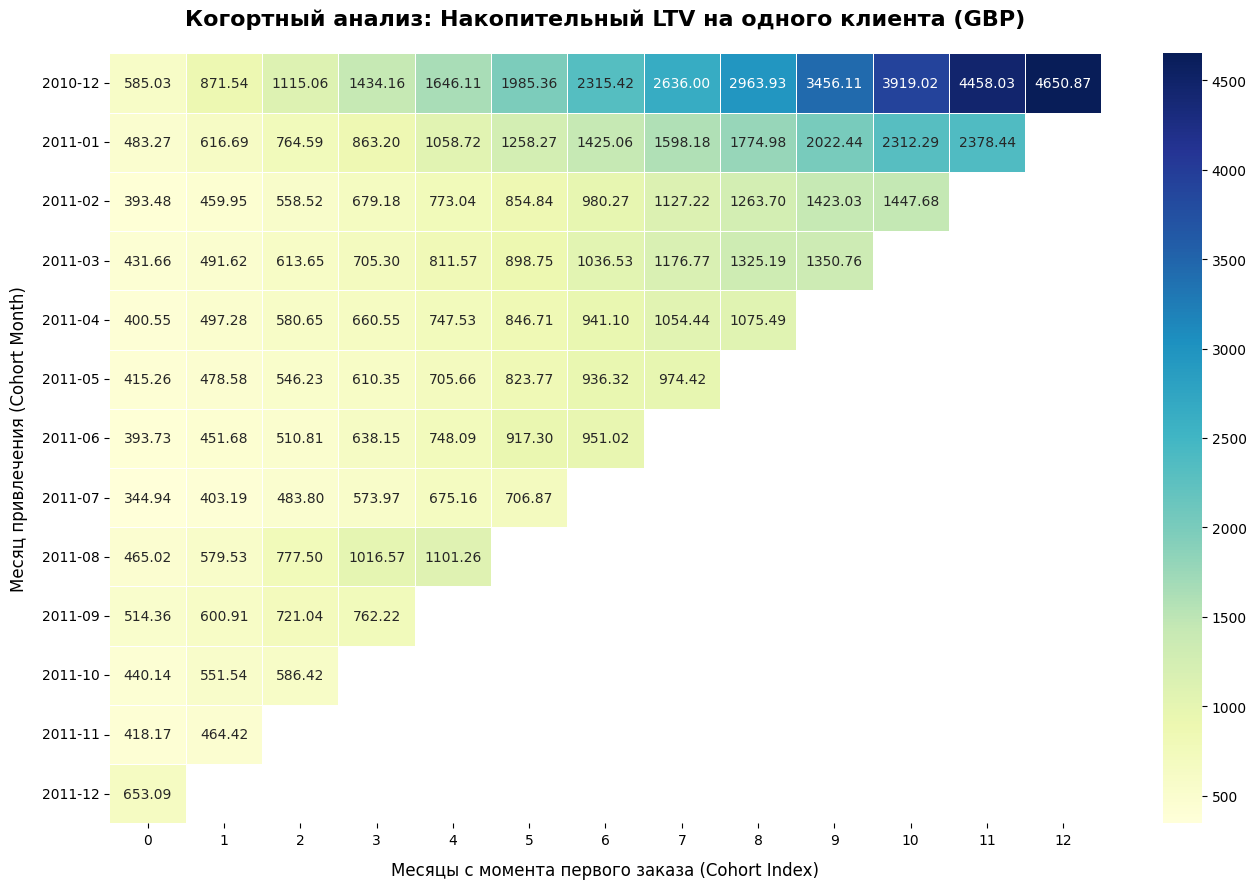

In [8]:
plt.figure(figsize=(16, 10))
sns.heatmap(
            ltv_matrix,
            annot=True,
            cmap='YlGnBu',
            fmt='.2f',
            linewidths=0.5
)
plt.title('Когортный анализ: Накопительный LTV на одного клиента (GBP)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Месяцы с момента первого заказа (Cohort Index)', fontsize=12, labelpad=10)
plt.ylabel('Месяц привлечения (Cohort Month)', fontsize=12, labelpad=10)
plt.yticks(rotation=0)
plt.savefig('ltv_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()